# K-Fold Validation — CLAP Classico vs ResiDualCLAP

Questo notebook esegue la K-Fold cross-validation su tutti i dataset
e produce i plot comparativi finali.

## 0. Configurazione globale
Imposta qui tutti i parametri prima di eseguire il notebook.

In [1]:
# ============================================================
# CONFIGURAZIONE — modifica questi valori
# ============================================================

# --- Device ---
USE_CUDA = False

# --- Percorsi ---
MODEL_PATH  = None          # None = download automatico da HuggingFace
OUTPUT_DIR  = 'kfolds'      # Directory dove salvare i risultati
DATA_ROOT   = '../data'      # Root dei dataset

# --- K-Fold ---
N_FOLDS     = 2             # Numero di fold
SEED        = 42            # Seed globale (tutto deterministico)
N_SAMPLES   = 100          # Campioni per dataset (campionamento stratificato)

# --- PCA (solo ResiDual) ---
N_PCA_SAMPLES   = 25       # Quanti campioni usare per il fitting PCA
PCA_BATCH_SIZE  = 1        # Batch size durante la raccolta PCA

# --- Lambda optimization (solo ResiDual) ---
LAMBDA_BATCH_SIZE = 16      # Batch size durante ottimizzazione λ
MAX_EPOCHS        = 2      # Epoche massime
PATIENCE          = 1       # Early stopping patience
LR                = 1e-2    # Learning rate per λ
DECAY             = 1e-2    # Weight decay per AdamW
VARIANCE_THRESH   = 0.95    # Soglia varianza cumulata per scelta k nelle PCA

# --- Valutazione ---
EVAL_BATCH_SIZE = 16        # Batch size per la valutazione zero-shot

# --- ResiDual config ---
RESIDUAL_CONFIG = {
    'target_layers':      [2, 3],
    'variance_threshold': VARIANCE_THRESH,
}

# 1. Import e setup

In [2]:
import warnings
warnings.filterwarnings('ignore')

import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch
import json
from pathlib import Path
from tqdm.notebook import tqdm

from CLAPWrapper import CLAPWrapper
from datasets.esc50  import ESC50
from datasets.irmas  import IRMAS
from datasets.tinysol    import TinySOL   
from datasets.vocalsound import VocalSound

from models.train_kfold import (
    run_kfold_residual,
    run_kfold_classic,
    load_all_results,
    set_seed,
)

set_seed(SEED)
print(f"CUDA disponibile: {torch.cuda.is_available()}")
print(f"Device: {'cuda' if USE_CUDA and torch.cuda.is_available() else 'cpu'}")

CUDA disponibile: False
Device: cpu


# 2. Caricamento dataset
Ogni dataset viene caricato una volta sola e riutilizzato per entrambe le versioni.

In [3]:
print("Caricamento ESC-50...")
esc50 = ESC50(root=DATA_ROOT, download=True)
print(f"  Campioni: {len(esc50)} | Classi: {len(esc50.classes)}")

print("\nCaricamento IRMAS...")
irmas = IRMAS(root=DATA_ROOT, download=True)
print(f"  Campioni: {len(irmas)} | Classi: {len(irmas.classes)}")

print("\nCaricamento TinySOL...")
tinysol = TinySOL(root=DATA_ROOT, download=True)

print("\nCaricamento VocalSound...")
vocalsound = VocalSound(root=DATA_ROOT, download=True)

# Dizionario dataset_name → dataset object
DATASETS = {
    'ESC50': esc50,
    'IRMAS': irmas,
    'TinySOL':    tinysol,
    'VocalSound': vocalsound,
}

Caricamento ESC-50...
Dataset già presente in ../data/ESC-50-master, skip download.
Loading audio files


  0%|          | 0/2000 [00:00<?, ?it/s]

100%|██████████| 2000/2000 [00:00<00:00, 14547.85it/s]

✓ Cache di validazione trovata (2026-04-01T21:46:58.127961): 2000 validi, 0 corrotti. Skip validazione.


  Campioni: 2000 | Classi: 50

Caricamento IRMAS...
Dataset già presente in ../data/IRMAS-TrainingData, skip download.
Loading IRMAS audio files...


...

  Totale campioni caricati: 6705
✓ Cache di validazione trovata (2026-04-09T18:59:59.216527): 6705 validi, 0 corrotti. Skip validazione.
  Campioni: 6705 | Classi: 11

Caricamento TinySOL...
Dataset già presente in ../data/TinySOL
Loading audio files


100%|██████████| 2913/2913 [00:00<00:00, 15723.66it/s]


✓ Cache di validazione trovata (2026-04-01T23:54:22.189250): 2913 validi, 0 corrotti. Skip validazione.

Caricamento VocalSound...
Dataset già presente in ../data/VocalSound
Loading audio files


100%|██████████| 21024/21024 [00:01<00:00, 18159.86it/s]

✓ Cache di validazione trovata (2026-04-02T01:44:11.836275): 20985 validi, 39 corrotti. Skip validazione.


# 3. K-Fold — CLAP Classico
Per ogni dataset esegue la K-Fold zero-shot evaluation senza ottimizzazione.

In [4]:
# Carica il modello CLAP classico
print("Caricamento CLAP classico...")
clap_classic = CLAPWrapper(
    model_fp = MODEL_PATH,
    version  = '2023',
    use_cuda = USE_CUDA,
    type     = 'classic',
)
print("  ✓ Modello caricato")

Caricamento CLAP classico...
  ✓ Modello caricato


In [5]:
# Esegui K-Fold classico su tutti i dataset
for dataset_name, dataset in DATASETS.items():
    print(f"\n{'='*60}")
    print(f"  Dataset: {dataset_name}")
    print(f"{'='*60}")

    run_kfold_classic(
        clap_wrapper    = clap_classic,
        dataset         = dataset,
        dataset_name    = dataset_name,
        n_folds         = N_FOLDS,
        n_samples       = N_SAMPLES,
        seed            = SEED,
        eval_batch_size = EVAL_BATCH_SIZE,
        use_cuda        = USE_CUDA,
        output_dir      = OUTPUT_DIR,
    )


  Dataset: ESC50

[Classic K-Fold] Calcolo text embeddings...


  Encoding text:   0%|          | 0/2 [00:00<?, ?it/s]

[Classic] ESC50 K-Fold:   0%|          | 0/2 [00:00<?, ?it/s]

  [Fold 1/2] Evaluating:   0%|          | 0/4 [00:00<?, ?it/s]

  Fold 1/2 | accuracy: 0.9000


...

[Classic] VocalSound K-Fold:   0%|          | 0/2 [00:00<?, ?it/s]

  [Fold 1/2] Evaluating:   0%|          | 0/4 [00:00<?, ?it/s]

  Fold 1/2 | accuracy: 0.7400


  [Fold 2/2] Evaluating:   0%|          | 0/4 [00:00<?, ?it/s]

  Fold 2/2 | accuracy: 0.7600

[Classic] VocalSound → mean=0.7500 ± 0.0100
  Risultati salvati in kfolds/VocalSound/classic_results.json


# 4. K-Fold — ResiDualCLAP
Per ogni dataset esegue K-Fold con fitting PCA e ottimizzazione λ.

In [6]:
# Carica il modello ResiDualCLAP
# NOTA: viene creato un nuovo wrapper per ogni dataset per resettare i pesi λ
print("Il modello ResiDual verrà caricato per ogni dataset (reset λ)")

Il modello ResiDual verrà caricato per ogni dataset (reset λ)


In [7]:
for dataset_name, dataset in DATASETS.items():
    print(f"\n{'='*60}")
    print(f"  Dataset: {dataset_name}")
    print(f"{'='*60}")

    # Ricarichiamo il modello ad ogni dataset per avere λ freschi
    clap_residual = CLAPWrapper(
        model_fp        = MODEL_PATH,
        version         = '2023',
        use_cuda        = USE_CUDA,
        type            = 'residual',
        residual_config = RESIDUAL_CONFIG,
    )

    run_kfold_residual(
        clap_wrapper        = clap_residual,
        dataset             = dataset,
        dataset_name        = dataset_name,
        residual_config     = RESIDUAL_CONFIG,
        n_folds             = N_FOLDS,
        n_samples           = N_SAMPLES,
        n_pca_samples       = N_PCA_SAMPLES,
        seed                = SEED,
        pca_batch_size      = PCA_BATCH_SIZE,
        lambda_batch_size   = LAMBDA_BATCH_SIZE,
        max_epochs          = MAX_EPOCHS,
        patience            = PATIENCE,
        lr                  = LR,
        wd                  = DECAY,
        variance_threshold  = VARIANCE_THRESH,
        eval_batch_size     = EVAL_BATCH_SIZE,
        use_cuda            = USE_CUDA,
        output_dir          = OUTPUT_DIR,
    )

    del clap_residual  # libera memoria


  Dataset: ESC50

[ResiDual K-Fold] Calcolo text embeddings...


  Encoding text:   0%|          | 0/2 [00:00<?, ?it/s]

[ResiDual] ESC50 K-Fold:   0%|          | 0/2 [00:00<?, ?it/s]


  Fold 1/2
  Train: 50 | PCA: 25 | Lambda: 25 | Test: 50

  [Fold 1] Fase 1: Fitting PCA...


[ResiDual] Raccolta per PCA:   0%|          | 0/25 [00:00<?, ?it/s]

...

  Epoch   1/2 | acc=0.6800 | best=-1.0000


    Optimizing λ:   0%|          | 0/2 [00:00<?, ?it/s]

  Epoch   2/2 | acc=0.7200 | best=0.6800
[ResiDual] Best accuracy: 0.7200 @ epoch 2

  [Fold 2] Fase 3: Valutazione zero-shot...


  [Fold 2/2] Evaluating:   0%|          | 0/4 [00:00<?, ?it/s]


  ✓ Fold 2 accuracy: 0.7000

[ResiDual] VocalSound → mean=0.7400 ± 0.0400
  Risultati salvati in kfolds/VocalSound/residual_results.json


# 5. Caricamento risultati e plot comparativi

In [8]:
all_results = load_all_results(OUTPUT_DIR)
print("Dataset con risultati:")
for name, res in all_results.items():
    classic_acc  = res['classic']['mean_accuracy']  if res['classic']  else 'N/A'
    residual_acc = res['residual']['mean_accuracy'] if res['residual'] else 'N/A'
    print(f"  {name:<15} classic={classic_acc:.4f}   residual={residual_acc:.4f}")

Dataset con risultati:
  ESC50           classic=0.9200   residual=0.9400
  IRMAS           classic=0.6200   residual=0.7400
  TinySOL         classic=0.3400   residual=0.4200
  VocalSound      classic=0.7500   residual=0.7400


In [9]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# ── palette e stile globale ──────────────────────────────────────────────────
C_CLASSIC  = '#4b707d'
C_RESIDUAL = "#6DA265"
C_GRID     = '#e8e8e8'
C_TEXT     = '#2c2c2a'
C_SUBTEXT  = '#6b6b68'
C_BG       = '#ffffff'
C_PANEL    = '#f7f7f5'

plt.rcParams.update({
    'font.family':        'sans-serif',
    'font.size':          11,
    'axes.spines.top':    False,
    'axes.spines.right':  False,
    'axes.spines.left':   True,
    'axes.spines.bottom': True,
    'axes.edgecolor':     '#ccccca',
    'axes.linewidth':     0.8,
    'axes.facecolor':     C_BG,
    'figure.facecolor':   C_BG,
    'text.color':         C_TEXT,
    'axes.labelcolor':    C_TEXT,
    'xtick.color':        C_SUBTEXT,
    'ytick.color':        C_SUBTEXT,
    'xtick.labelsize':    10,
    'ytick.labelsize':    10,
    'axes.labelsize':     11,
    'axes.titlesize':     12,
    'axes.titleweight':   'bold',
    'axes.titlecolor':    C_TEXT,
    'legend.frameon':     False,
    'legend.fontsize':    10,
})

dataset_names  = list(all_results.keys())
classic_means  = [all_results[n]['classic']['mean_accuracy']  if all_results[n]['classic']  else 0 for n in dataset_names]
classic_stds   = [all_results[n]['classic']['std_accuracy']   if all_results[n]['classic']  else 0 for n in dataset_names]
residual_means = [all_results[n]['residual']['mean_accuracy'] if all_results[n]['residual'] else 0 for n in dataset_names]
residual_stds  = [all_results[n]['residual']['std_accuracy']  if all_results[n]['residual'] else 0 for n in dataset_names]
n_datasets     = len(dataset_names)

legend_patches = [
    mpatches.Patch(color=C_CLASSIC,  label='CLAP Classic'),
    mpatches.Patch(color=C_RESIDUAL, label='ResiDualCLAP'),
]

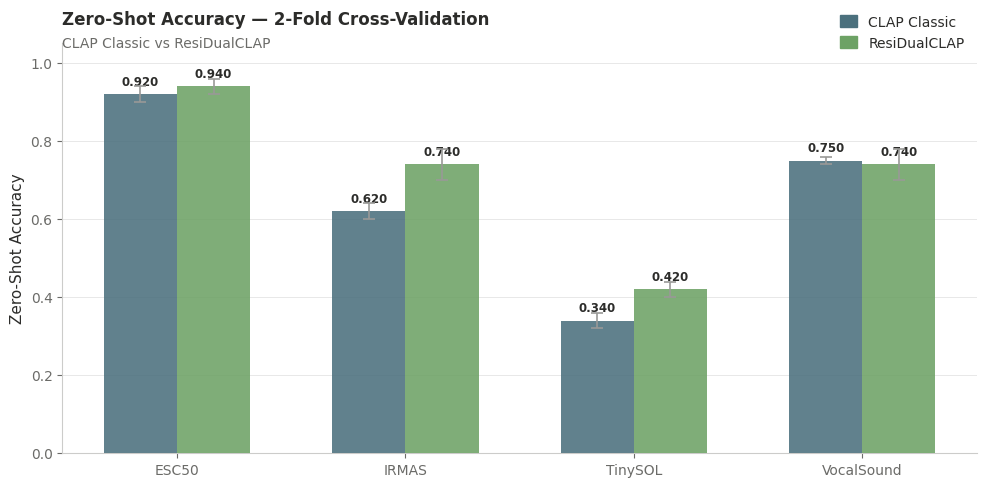

In [10]:
# ============================================================
# PLOT 1 — Bar chart
# ============================================================

x        = np.arange(n_datasets)
width    = 0.32
error_kw = dict(elinewidth=1.2, ecolor='#999997', capsize=4, capthick=1.2)

fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor(C_BG)

bars1 = ax.bar(x - width/2, classic_means,  width,
               yerr=classic_stds,  error_kw=error_kw,
               color=C_CLASSIC,  alpha=0.88, label='CLAP Classic',
               zorder=3)
bars2 = ax.bar(x + width/2, residual_means, width,
               yerr=residual_stds, error_kw=error_kw,
               color=C_RESIDUAL, alpha=0.88, label='ResiDualCLAP',
               zorder=3)

for bar in list(bars1) + list(bars2):
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2,
            h + 0.016, f'{h:.3f}',
            ha='center', va='bottom',
            fontsize=8.5, color=C_TEXT, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(dataset_names)
ax.set_ylabel('Zero-Shot Accuracy')
ax.set_ylim(0, min(1.05, max(max(classic_means), max(residual_means)) + 0.18))
ax.yaxis.grid(True, color=C_GRID, linewidth=0.7, zorder=0)
ax.set_axisbelow(True)

# titolo a sinistra, legenda a destra alla stessa altezza
ax.set_title(f'Zero-Shot Accuracy — {N_FOLDS}-Fold Cross-Validation',
             pad=14, loc='left')
ax.text(0, 0.99, 'CLAP Classic vs ResiDualCLAP',
        transform=ax.transAxes, fontsize=10, color=C_SUBTEXT)

ax.legend(handles=legend_patches,
          loc='upper right',
          bbox_to_anchor=(1.0, 1.1),
          handlelength=1.2, handleheight=0.9)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/plot_bar_accuracy.png', dpi=180, bbox_inches='tight')
plt.show()

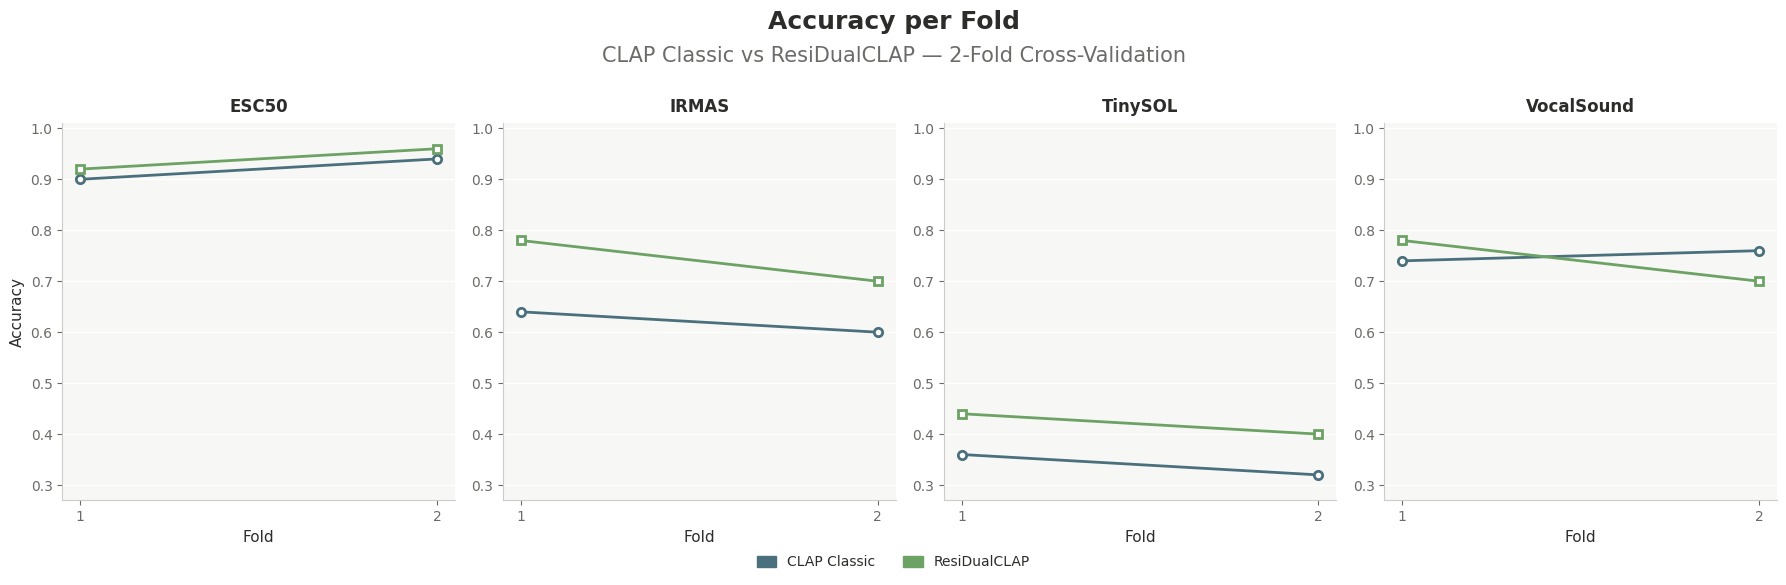

In [11]:
# ============================================================
# PLOT 2 — Fold-by-fold accuracy  (legenda unica in basso al centro)
# ============================================================

fig, axes = plt.subplots(1, n_datasets,
                         figsize=(4.5 * n_datasets, 5.2),
                         sharey=False)
if n_datasets == 1:
    axes = [axes]

fold_ids = list(range(1, N_FOLDS + 1))

# calcola range y globale su tutti i dataset
all_fold_accs = []
for name in dataset_names:
    res = all_results[name]
    if res['classic']:
        all_fold_accs += [f['accuracy'] for f in res['classic']['folds']]
    if res['residual']:
        all_fold_accs += [f['accuracy'] for f in res['residual']['folds']]

y_min = max(0.0,  min(all_fold_accs) - 0.05)
y_max = min(1.01, max(all_fold_accs) + 0.05)

for ax, name in zip(axes, dataset_names):
    res = all_results[name]
    ax.set_facecolor(C_PANEL)
    ax.yaxis.grid(True, color=C_BG, linewidth=1.0, zorder=0)
    ax.set_axisbelow(True)

    if res['classic']:
        vals = [f['accuracy'] for f in res['classic']['folds']]
        ax.plot(fold_ids, vals, 'o-',
                color=C_CLASSIC, linewidth=2, markersize=6,
                markerfacecolor=C_BG, markeredgewidth=2,
                zorder=3)

    if res['residual']:
        vals = [f['accuracy'] for f in res['residual']['folds']]
        ax.plot(fold_ids, vals, 's-',
                color=C_RESIDUAL, linewidth=2, markersize=6,
                markerfacecolor=C_BG, markeredgewidth=2,
                zorder=3)

    ax.set_ylim(y_min, y_max)
    ax.set_title(name, pad=8)
    ax.set_xlabel('Fold')
    ax.set_xticks(fold_ids)
    if ax == axes[0]:
        ax.set_ylabel('Accuracy')
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)

fig.suptitle('Accuracy per Fold',
             fontsize=18, fontweight='bold',
             color=C_TEXT, y=1.06, x=0.5, ha='center')
fig.text(0.5, 0.99,
         f'CLAP Classic vs ResiDualCLAP — {N_FOLDS}-Fold Cross-Validation',
         fontsize=15, color=C_SUBTEXT,
         ha='center', va='top')

fig.legend(handles=legend_patches,
           loc='lower center',
           bbox_to_anchor=(0.5, -0.04),
           ncol=2,
           handlelength=1.4, handleheight=0.9,
           columnspacing=2.0)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/plot_folds_accuracy.png', dpi=180, bbox_inches='tight')
plt.show()

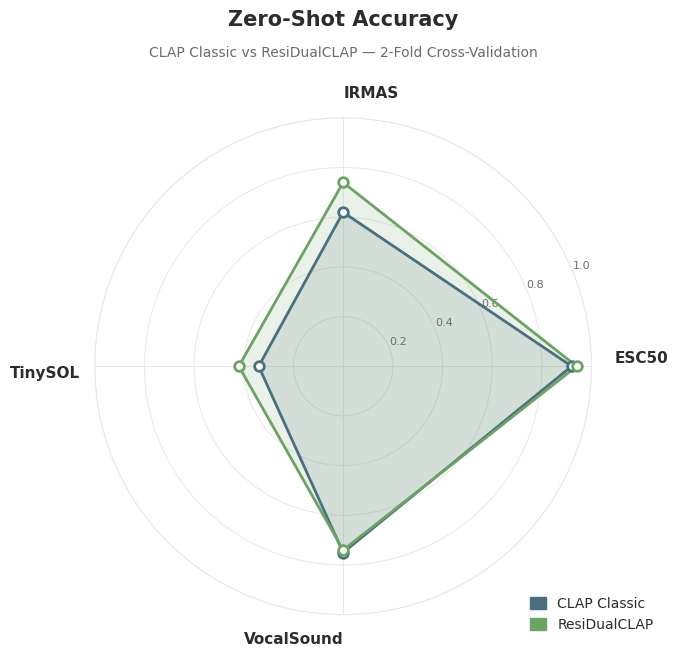

In [12]:
# ============================================================
# PLOT 3 — Spider / Radar chart  (4 dataset, semplificato)
# ============================================================

N      = 4
labels = dataset_names[:4]   # assume 4 dataset

angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

classic_vals  = classic_means[:4]  + [classic_means[0]]
residual_vals = residual_means[:4] + [residual_means[0]]

fig, ax = plt.subplots(figsize=(6.5, 7.2), subplot_kw=dict(polar=True))
fig.patch.set_facecolor(C_BG)
ax.set_facecolor(C_BG)

# plot + legenda spostati più in basso rispetto alla versione precedente
ax.set_position([0.1, 0.08, 0.8, 0.69])

ax.set_ylim(0, 1)
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels(['0.2', '0.4', '0.6', '0.8', '1.0'],
                   fontsize=8, color=C_SUBTEXT)
ax.yaxis.grid(True, color=C_GRID, linewidth=0.7)
ax.xaxis.grid(True, color=C_GRID, linewidth=0.7)
ax.spines['polar'].set_color(C_GRID)

ax.plot(angles, classic_vals,  color=C_CLASSIC,  linewidth=2, zorder=3)
ax.fill(angles, classic_vals,  color=C_CLASSIC,  alpha=0.15, zorder=2)
ax.scatter(angles[:-1], classic_vals[:-1],
           s=48, zorder=4,
           facecolors=C_BG, edgecolors=C_CLASSIC, linewidths=2)

ax.plot(angles, residual_vals, color=C_RESIDUAL, linewidth=2, zorder=3)
ax.fill(angles, residual_vals, color=C_RESIDUAL, alpha=0.15, zorder=2)
ax.scatter(angles[:-1], residual_vals[:-1],
           s=48, zorder=4,
           facecolors=C_BG, edgecolors=C_RESIDUAL, linewidths=2)

ax.set_xticks(angles[:-1])
ax.set_xticklabels([])

for i, (angle, label) in enumerate(zip(angles[:-1], labels)):
    deg = np.degrees(angle) % 360

    # Con 4 dataset gli angoli sono esattamente 0°, 90°, 180°, 270°
    # Nord (0°) e Sud (180°) → centrati e più vicini al plot
    # Est (90°) e Ovest (270°) → allineati lateralmente

    if deg < 5 or deg > 355:        # DX
        ha, va   = 'center', 'bottom'
        radius   = 1.2            # più vicino rispetto a 1.18
    elif 175 < deg < 185:           # SX
        ha, va   = 'center', 'top'
        radius   = 1.2             # più vicino rispetto a 1.18
    elif 0 < deg < 180:             # Nord
        ha, va   = 'left', 'center'
        radius   = 1.1
    else:                           # SUD
        ha, va   = 'right', 'center'
        radius   = 1.1

    ax.text(angle, radius, label,
            ha=ha, va=va,
            fontsize=11, fontweight='bold', color=C_TEXT,
            transform=ax.get_xaxis_transform())

ax.set_title('', pad=0)

# titoli spostati leggermente più in basso insieme al plot
fig.text(0.5, 0.92,
         'Zero-Shot Accuracy',
         fontsize=15, fontweight='bold',
         color=C_TEXT, ha='center', va='top')
fig.text(0.5, 0.87,
         f'CLAP Classic vs ResiDualCLAP — {N_FOLDS}-Fold Cross-Validation',
         fontsize=10, color=C_SUBTEXT,
         ha='center', va='top')

# legenda in basso a destra, ancorata al nuovo layout
ax.legend(handles=legend_patches,
          loc='lower right',
          bbox_to_anchor=(1.15, -0.06),
          handlelength=1.2, handleheight=0.9)

plt.savefig(f'{OUTPUT_DIR}/plot_spider_accuracy.png',
            dpi=180, bbox_inches='tight')
plt.show()

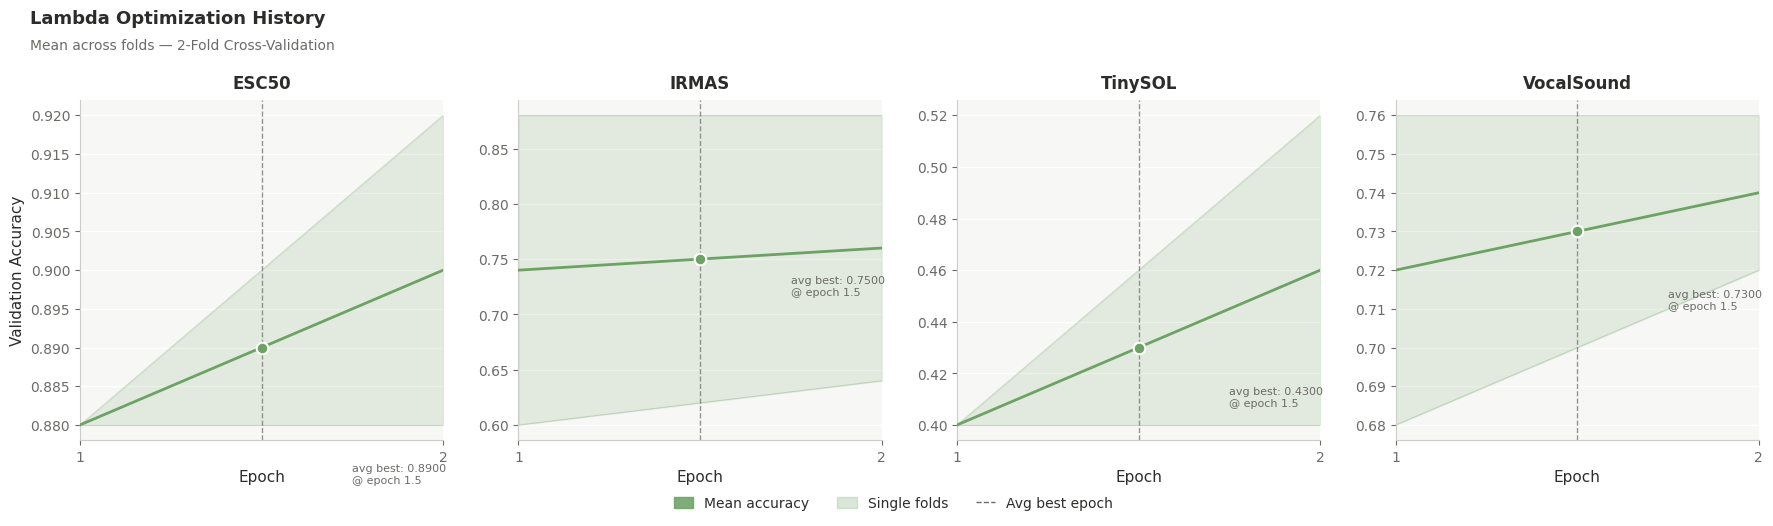

In [13]:
# ============================================================
# PLOT 4 — Lambda optimization history (media su tutti i fold)
# ============================================================

fig, axes = plt.subplots(1, n_datasets,
                         figsize=(4.5 * n_datasets, 4.8),
                         sharey=False)
if n_datasets == 1:
    axes = [axes]

legend_handles_p4 = [
    mpatches.Patch(color=C_RESIDUAL, alpha=0.88, label='Mean accuracy'),
    mpatches.Patch(color=C_RESIDUAL, alpha=0.25, label='Single folds'),
    plt.Line2D([0], [0], color=C_SUBTEXT, linewidth=1,
               linestyle='--', label='Avg best epoch'),
]

for ax, name in zip(axes, dataset_names):
    res = all_results[name]
    ax.set_facecolor(C_PANEL)
    ax.yaxis.grid(True, color=C_BG, linewidth=1.0, zorder=0)
    ax.set_axisbelow(True)

    if res['residual'] and res['residual']['folds']:
        folds         = res['residual']['folds']
        all_histories = [f.get('lambda_history', []) for f in folds
                         if f.get('lambda_history')]

        if all_histories:
            max_len = max(len(h) for h in all_histories)
            padded  = np.array([
                h + [h[-1]] * (max_len - len(h))
                for h in all_histories
            ])
            mean_acc = padded.mean(axis=0)
            std_acc  = padded.std(axis=0)
            epochs   = range(1, max_len + 1)

            # linee singoli fold in trasparenza
            for h in all_histories:
                ax.plot(range(1, len(h) + 1), h,
                        color=C_RESIDUAL, linewidth=0.7,
                        alpha=0.25, zorder=1)

            # banda ±std e linea media
            ax.fill_between(epochs,
                            mean_acc - std_acc,
                            mean_acc + std_acc,
                            color=C_RESIDUAL, alpha=0.15, zorder=2)
            ax.plot(epochs, mean_acc,
                    color=C_RESIDUAL, linewidth=2, zorder=3)

            # best epoch medio — pallina sulla curva media
            best_epochs = [f['best_lambda_epoch'] for f in folds
                           if 'best_lambda_epoch' in f]
            if best_epochs:
                mean_best_ep = np.mean(best_epochs)

                # interpola mean_acc per trovare il valore esatto alla best epoch media
                ep_floor  = int(np.floor(mean_best_ep)) - 1   # indice 0-based
                ep_ceil   = min(int(np.ceil(mean_best_ep)) - 1, max_len - 1)
                frac      = mean_best_ep - np.floor(mean_best_ep)
                mean_best_acc_on_curve = (
                    mean_acc[ep_floor] * (1 - frac) + mean_acc[ep_ceil] * frac
                )

                ax.axvline(mean_best_ep, linestyle='--',
                           color=C_SUBTEXT, linewidth=1, alpha=0.7, zorder=2)
                ax.scatter([mean_best_ep], [mean_best_acc_on_curve],
                           color=C_RESIDUAL, s=70, zorder=5,
                           edgecolors=C_BG, linewidths=1.5)
                ax.text(mean_best_ep + 0.25, mean_best_acc_on_curve - 0.015,
                        f'avg best: {mean_best_acc_on_curve:.4f}\n@ epoch {mean_best_ep:.1f}',
                        fontsize=8, color=C_SUBTEXT, va='top')

    ax.set_title(name, pad=8)
    ax.set_xlabel('Epoch')
    ax.set_xlim(1, MAX_EPOCHS)
    ax.set_xticks(range(1, MAX_EPOCHS + 1, max(1, MAX_EPOCHS // 10)))
    if ax == axes[0]:
        ax.set_ylabel('Validation Accuracy')
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)

fig.suptitle('Lambda Optimization History',
             fontsize=13, fontweight='bold',
             color=C_TEXT, y=1.03, x=0.02, ha='left')
fig.text(0.02, 0.97,
         f'Mean across folds — {N_FOLDS}-Fold Cross-Validation',
         fontsize=10, color=C_SUBTEXT,
         ha='left', va='top')

fig.legend(handles=legend_handles_p4,
           loc='lower center',
           bbox_to_anchor=(0.5, -0.04),
           ncol=3,
           handlelength=1.4, handleheight=0.9,
           columnspacing=2.0)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/plot_lambda_history.png', dpi=180, bbox_inches='tight')
plt.show()

In [14]:
# ============================================================
# Riepilogo finale testuale
# ============================================================

print("\n" + "="*55)
print("  RIEPILOGO FINALE")
print("="*55)
print(f"{'Dataset':<15} {'Classic':>10} {'ResiDual':>10} {'Delta':>8}")
print("-"*55)
for name in dataset_names:
    c = all_results[name]['classic']['mean_accuracy']  if all_results[name]['classic']  else 0
    r = all_results[name]['residual']['mean_accuracy'] if all_results[name]['residual'] else 0
    delta = r - c
    sign  = '+' if delta >= 0 else ''
    print(f"{name:<15} {c:>10.4f} {r:>10.4f} {sign+f'{delta:.4f}':>8}")
print("="*55)


  RIEPILOGO FINALE
Dataset            Classic   ResiDual    Delta
-------------------------------------------------------
ESC50               0.9200     0.9400  +0.0200
IRMAS               0.6200     0.7400  +0.1200
TinySOL             0.3400     0.4200  +0.0800
VocalSound          0.7500     0.7400  -0.0100
